# EE446 - TinyML - Assignment 2

## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/homebrew/Cellar/python@3.11/3.11.15/Frameworks/Python.framework/Versions/3.11/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/homebrew/Cellar/python@3.11/3.11.15/Frameworks/Python.framework/Versions/3.11/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/Users/meghangillen/ai/projects/tinyml-arduino/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  Fil

## Reading Data

In [3]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [4]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [5]:
## INSERT YOUR CODE HERE ##
data = data.drop(
    ['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'],
    axis=1
)

##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [6]:
## INSERT YOUR CODE HERE ##
data['attack'] = data['attack'].apply(
    lambda x: 'normal' if x == 'normal' else 'attack'
)

In [7]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [8]:
## INSERT YOUR CODE HERE ##
for col in ['protocoltype', 'service', 'flag', 'attack']:
    data[col] = LabelEncoder().fit_transform(data[col])

In [9]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [10]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

In [11]:
print(type(X_test), np.shape(X_test))
print(type(y_test), np.shape(y_test))
print("unique labels:", np.unique(y_test))

<class 'numpy.ndarray'> (25195, 38)
<class 'numpy.ndarray'> (25195, 1)
unique labels: [0 1]


## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

X_test shape: (25195, 38)
y_test shape: (25195,)
labels: [0 1]
attack points: 13520
normal points: 11675


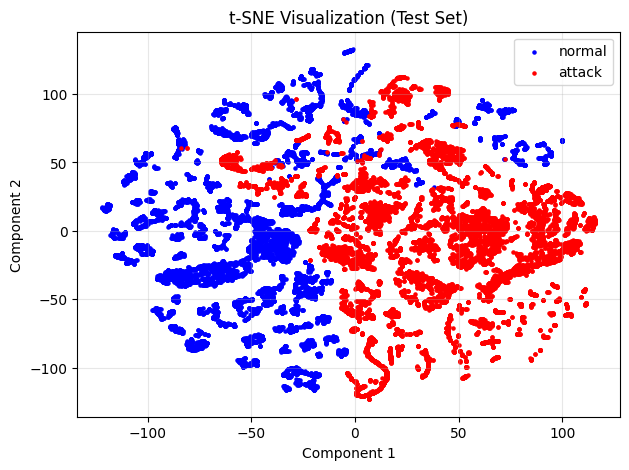

In [12]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# ensure arrays
X_test = np.array(X_test)
y_test = np.array(y_test).ravel()

# safety check
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("labels:", np.unique(y_test))

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_test)

# masks (adjust if needed)
attack_mask = (y_test == 1)
normal_mask = (y_test == 0)

print("attack points:", np.sum(attack_mask))
print("normal points:", np.sum(normal_mask))

# plot
plt.figure(figsize=(7,5))

plt.scatter(X_tsne[normal_mask, 0], X_tsne[normal_mask, 1],
            c='blue', s=5, label='normal')

plt.scatter(X_tsne[attack_mask, 0], X_tsne[attack_mask, 1],
            c='red', s=5, label='attack')

plt.title("t-SNE Visualization (Test Set)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

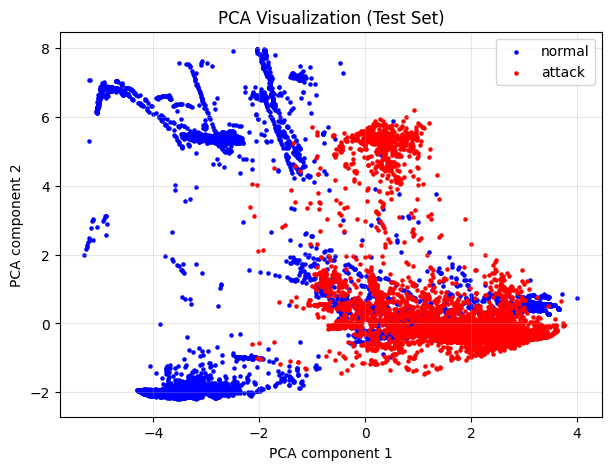

In [13]:
from sklearn.decomposition import PCA
## INSERT YOUR CODE HERE ##
pca = PCA(n_components=2)
pca.fit(X_train)

X_pca = pca.transform(X_test)
y_test = np.array(y_test).ravel()

attack_mask = (y_test == 1)
normal_mask = (y_test == 0)

plt.figure(figsize=(7,5))

plt.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
            c='blue', s=5, label='normal')

plt.scatter(X_pca[attack_mask, 0], X_pca[attack_mask, 1],
            c='red', s=5, label='attack')

plt.title("PCA Visualization (Test Set)")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [14]:
print(X_train.shape)

(100778, 38)


##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

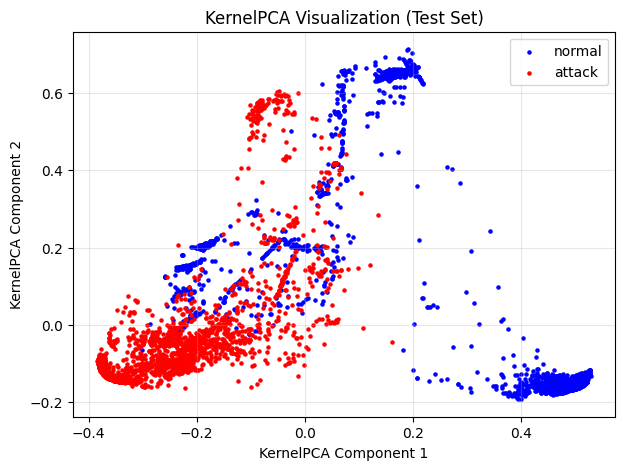

In [15]:
from sklearn.decomposition import KernelPCA
## INSERT YOUR CODE HERE ##
# Kernel was dying otherwise. 
subset_size = 3000
idx = np.random.choice(len(X_train), subset_size, replace=False)

kpca = KernelPCA(
    n_components=2,
    kernel='rbf',
    gamma=0.01
)

kpca.fit(X_train[idx])

X_test_small = X_test[:5000]
y_test_small = np.array(y_test[:5000]).ravel()

X_kpca = kpca.transform(X_test_small)

attack_mask = (y_test_small == 1)
normal_mask = (y_test_small == 0)

plt.figure(figsize=(7, 5))

plt.scatter(
    X_kpca[normal_mask, 0],
    X_kpca[normal_mask, 1],
    c='blue',
    s=5,
    label='normal'
)

plt.scatter(
    X_kpca[attack_mask, 0],
    X_kpca[attack_mask, 1],
    c='red',
    s=5,
    label='attack'
)

plt.title("KernelPCA Visualization (Test Set)")
plt.xlabel("KernelPCA Component 1")
plt.ylabel("KernelPCA Component 2")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [16]:
# Define the DNN model
base_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(2, activation='softmax')
])

##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [17]:
## INSERT YOUR CODE HERE ##
base_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

base_model.fit(
    X_train,
    y_train,
    epochs=30, 
    batch_size=8, 
    verbose=1
)

Epoch 1/30
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 5s 361us/step - accuracy: 0.9872 - loss: 0.0396
Epoch 2/30
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 5s 360us/step - accuracy: 0.9954 - loss: 0.0143
Epoch 3/30
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 4s 353us/step - accuracy: 0.9961 - loss: 0.0113
Epoch 4/30
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 5s 362us/step - accuracy: 0.9965 - loss: 0.0106
Epoch 5/30
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 5s 362us/step - accuracy: 0.9966 - loss: 0.0100
Epoch 6/30
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 5s 363us/step - accuracy: 0.9967 - loss: 0.0091
Epoch 7/30
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 5s 361us/step - accuracy: 0.9970 - loss: 0.0088
Epoch 8/30
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 5s 365us/step - accuracy: 0.9969 - loss: 0.0088
Epoch 9/30
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 5s 366us/step - accuracy: 0.9972 - loss: 0.0082
Epoch 10/30
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 5s 366us/step - accuracy: 0.9973 - loss: 0.0079
Epoch 11/30
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 4s 351us/step - accuracy: 0.9972 -

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

In [18]:
## INSERT YOUR CODE HERE ##
y_pred = np.argmax(
    base_model.predict(X_test, verbose=0), 
    axis=1
)

print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11675
           1       1.00      1.00      1.00     13520

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

[[11663    12]
 [   47 13473]]


In [19]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.

In [20]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

## INSERT YOUR CODE HERE ##
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpag84xykj/assets


INFO:tensorflow:Assets written to: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpag84xykj/assets


Saved artifact at '/var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpag84xykj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 38), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  6003138128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003137552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003135824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003137936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003132944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003145424: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1780415018.753293  257592 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1780415018.753528  257592 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1780415018.758061  257592 reader.cc:83] Reading SavedModel from: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpag84xykj
I0000 00:00:1780415018.758285  257592 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1780415018.758288  257592 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpag84xykj
I0000 00:00:1780415018.761281  257592 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1780415018.761731  257592 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1780415018.773274  257592 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpag84xykj
I0000 00:00:1780415018.776306  257592 lo

In [21]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 36.00 KB
Quantized model size: 3.54 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

In [22]:
## INSERT YOUR CODE HERE ##
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_pred_quant = []

for i in range(len(X_test)):
    sample = X_test[i].astype(np.float32).reshape(1, -1)

    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    pred_class = np.argmax(output)

    y_pred_quant.append(pred_class)

y_pred_quant = np.array(y_pred_quant)

print(classification_report(y_test, y_pred_quant, zero_division=0))
print(confusion_matrix(y_test, y_pred_quant))

TypeError: CreateWrapperFromBuffer(): incompatible function arguments. The following argument types are supported:
    1. (arg0: bytes, arg1: int, arg2: List[str], arg3: bool, arg4: bool) -> tflite::interpreter_wrapper::InterpreterWrapper
    2. (arg0: bytes, arg1: int, arg2: List[str], arg3: List[Callable[[int], None]], arg4: bool, arg5: bool) -> tflite::interpreter_wrapper::InterpreterWrapper

Invoked with: b'\x1c\x00\x00\x00TFL3\x14\x00 \x00\x1c\x00\x18\x00\x14\x00\x10\x00\x0c\x00\x00\x00\x08\x00\x04\x00\x14\x00\x00\x00\x1c\x00\x00\x00\x94\x00\x00\x00\xec\x00\x00\x00\xa4\x07\x00\x00\xb4\x07\x00\x00\xc0\r\x00\x00\x03\x00\x00\x00\x01\x00\x00\x00\x10\x00\x00\x00\x00\x00\n\x00\x10\x00\x0c\x00\x08\x00\x04\x00\n\x00\x00\x00\x0c\x00\x00\x00\x1c\x00\x00\x00<\x00\x00\x00\x0f\x00\x00\x00serving_default\x00\x01\x00\x00\x00\x04\x00\x00\x00\x94\xff\xff\xff\n\x00\x00\x00\x04\x00\x00\x00\x08\x00\x00\x00output_0\x00\x00\x00\x00\x01\x00\x00\x00\x04\x00\x00\x00B\xf8\xff\xff\x04\x00\x00\x00\x0b\x00\x0

## Converting tflite_model to C and create the header file

In [ ]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [ ]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [ ]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

In [ ]:
ytest=y_test[0:5]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

In [23]:
# Next 10 samples
Xtest = X_test[5:15,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 10;
const unsigned int X_test_dim2 = 38;

const float X_test[10][38] = {
    -0.11024922321249885, -0.12470615670462068, -0.442083085231092, 
    0.7511112872365361, -0.007722038419881614, -0.00483732645010989, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701655, 
    -0.01166364260376003, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.026180024184542783, -0.018609896340735923, 
    -0.041221197593275305, -0.0028174939213690773, -0.0975309439715147, 
    -0.7083124892864261, -0.20290185734466074, -0.6372092679572259, 
    -0.6319290328885425, -0.37436223991967527, -0.3744316031053049, 
    0.7712831058493207, -0.349683030873482, 0.8185305320037597, 
    -0.5055040619806033, 1.2587542737799418, 1.0664013456654928, 
    -0.43907816809041417, -0.4478339589698615, -0.11142568757652836, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.11024922321

In [24]:
# Next 10 samples
ytest = y_test[5:15]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 10;

const uint8_t y_test[10] = {
    1, 0, 0, 0, 0, 0, 1, 1, 0, 1
};

